# Function Transformer

Data becomes much easier to work with if it's normally distributed. Datasets, usually are not distributed normally and hence our beloved sklean offers three major transformers to transform our data to have normal distribution. These are :
- Function Transformer
- Power Transformer
- Quantile Transformer

Out of these, the first two are the most commonly used. Function Transformer class offers basic transformation methods and also allows the user to custom create a method. Power Transformer offers more advanced methods.
- Function transformer offers : 
    - Log transform
    - Reciprocal transform
    - Square root transform

- Power transformer
    - Box-cox transform
    - Yeo-Johnson transform

### How do you check whether your data is normal or not?
1. sns.kdeplot() //using seaborn and simply plotting the data 
2. pd.skew() //if 0 then normal otherwise skewed to one of the directions
3. QQ Plot [Basic basic interpretation : the more the points lie on the 45 degree slope line, the closer the distribution is to normal]

Ex : 
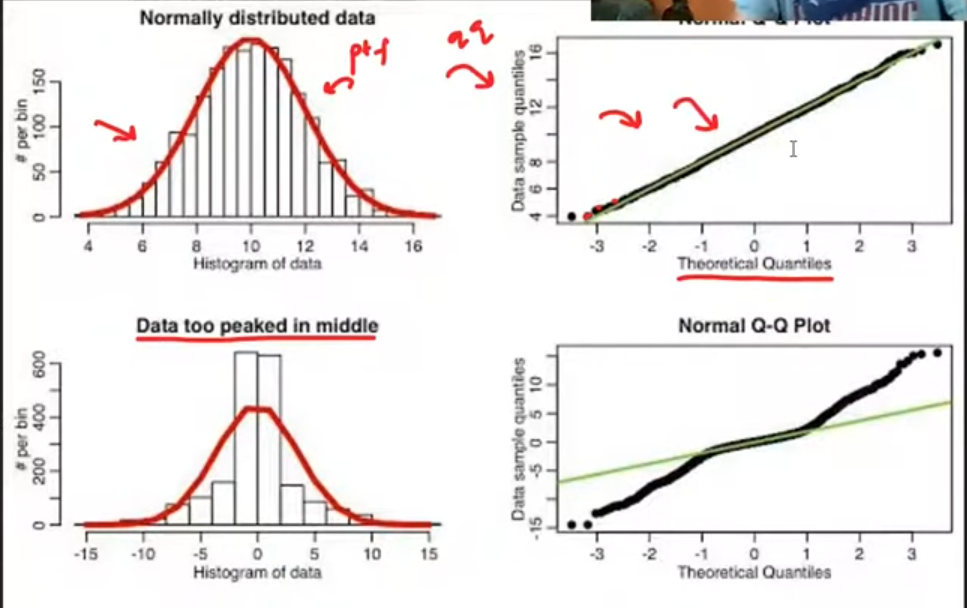

## Log Transform
Log transform is usually used to center the data which is **right skewed**. Also, it is used for data which does not have negative values because you can't pass negative values to log, obviously. 

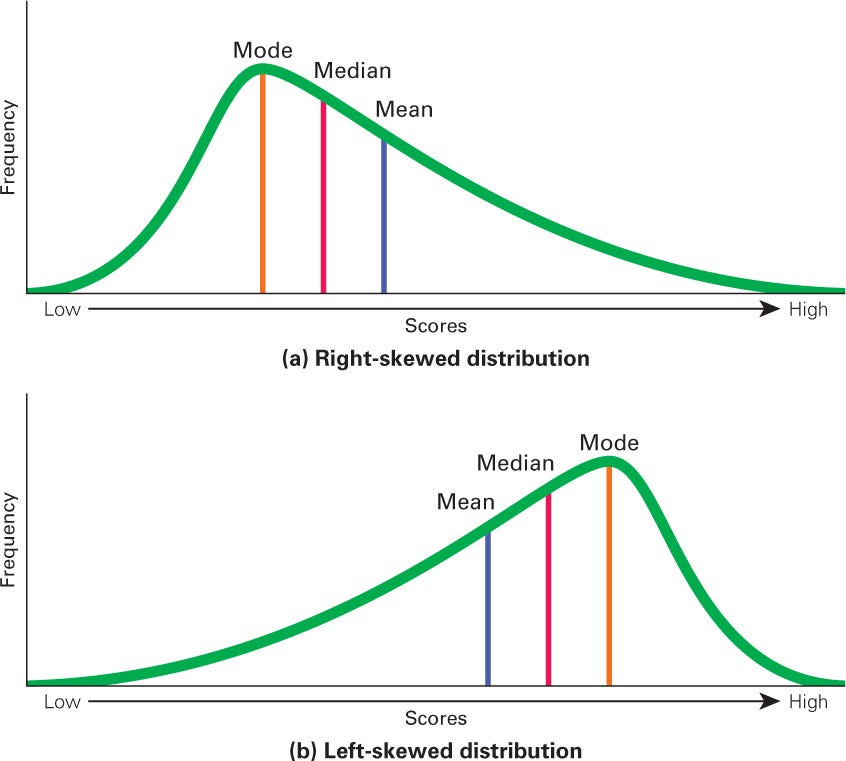

Log transform works by simply taking the log of all the values in the col.

Log brings down the multiplicative scale to the additive scale {10, 100, 1000 ... are equally spaced for log} hence, bringing the distribution towards normal. 

### Reciprocal transform (1/x)
the reciprocal transform simply takes reciprocal of all the values. So, all the smaller values become larger and the larger values become smaller. Useful in certain cases, though mostly found through experimentation.

### Square transform(x^2)
Take square of all values. Used for **left skewed data**

### Square Root transform
Square root of all values. Experimentation


## Example 
Seeing through example how applying these transforms improves accuracy.

In [33]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn. metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [34]:
df = pd.read_csv('../3_eda/titanic.csv', usecols=['Age', 'Fare', 'Survived'])

In [35]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [37]:
# Since age has missing values, dealing with those first
df.fillna({'Age': df['Age'].mean()}, inplace=True) #replace null values with the mean value

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [38]:
#Train-test split
X = df.iloc[ : , 1:]
y = df.iloc[ : , 0 ]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.head())
print("\n", y_train.head())

      Age     Fare
331  45.5  28.5000
733  23.0  13.0000
382  32.0   7.9250
704  26.0   7.8542
813   6.0  31.2750

 331    0
733    0
382    0
704    0
813    0
Name: Survived, dtype: int64


## Looking at the distributions of the cols
(Using PDF and QQ plot)

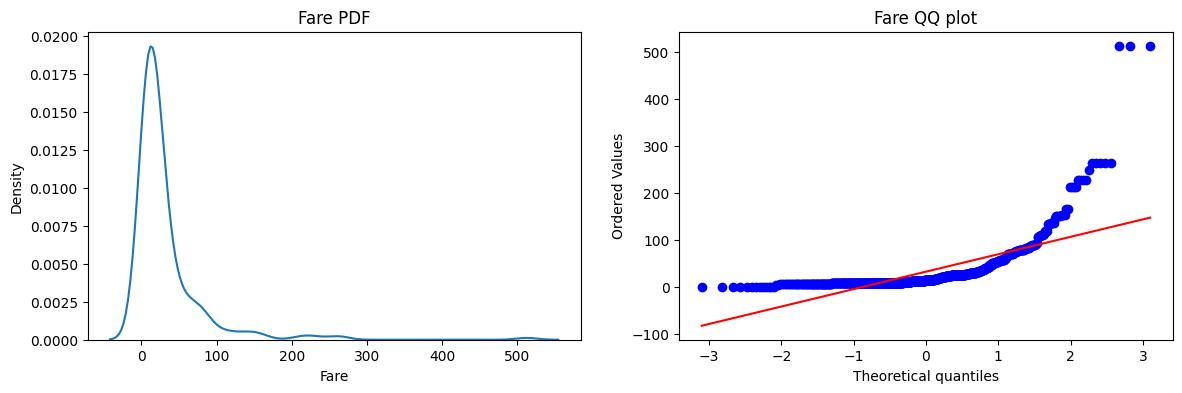

In [39]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.kdeplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ plot')

plt.show()

Here we can see that the plot is right skewed. 

Doing the same for the Age col

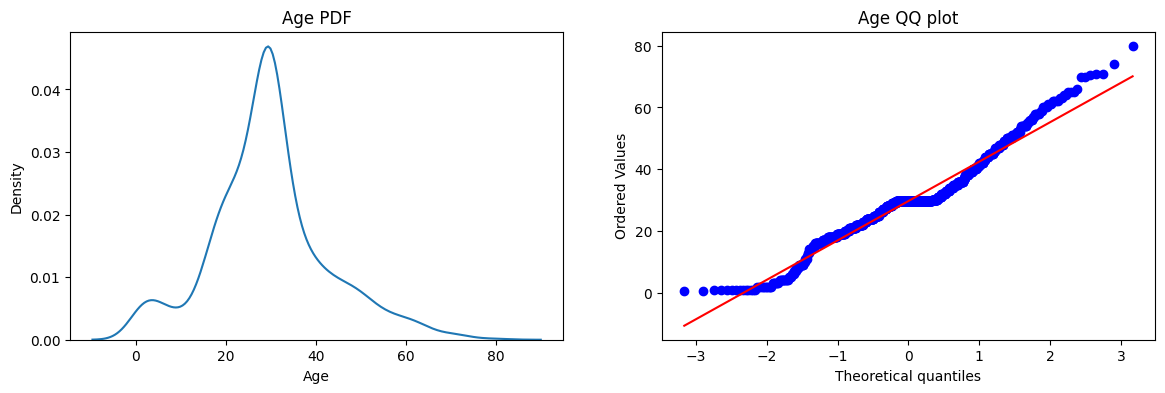

In [40]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.kdeplot(df['Age'])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(df['Age'], dist='norm', plot=plt)
plt.title('Age QQ plot')

plt.show()

This is mucuh closer to normal distribution than the Fare col

## Training models and evaluating performance before normal function transformations

In [41]:
# create the classifier objects
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [42]:
# Training and evaluating
#Fitting
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

#Predicting
y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

#Evaluate(accuracy)
accuracy = accuracy_score(y_test, y_pred)
accuracy2 = accuracy_score(y_test, y_pred2)

print("Logistic Regression Accuracy : ", accuracy)
print("\n Decision tree classification Accuracy : ", accuracy2)

Logistic Regression Accuracy :  0.6480446927374302

 Decision tree classification Accuracy :  0.6815642458100558


In [43]:
#function transformer object
trf = FunctionTransformer(func=np.log1p) #log1p adds 1 to each element, then applies log (safety against 0 value)

In [44]:
#Applying transformation
X_train_trfed = trf.fit_transform(X_train)
X_test_trfed = trf.transform(X_test)

In [ ]:
#train, predict and eval again
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

#Fitting
clf.fit(X_train_trfed, y_train)
clf2.fit(X_train_trfed, y_train)

#Predicting
y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

#Evaluate(accuracy)
accuracy = accuracy_score(y_test, y_pred)
accuracy2 = accuracy_score(y_test, y_pred2)
9
print("Logistic Regression Accuracy : ", accuracy)
print("\n Decision tree classification Accuracy : ", accuracy2)

Logistic Regression Accuracy :  0.7374301675977654

 Decision tree classification Accuracy :  0.5921787709497207


Note that the accuracy of Logistic Regression shot up, while the same for Decision Trees decreased. So you should try all tansforms until you find the best outputs.

## Verifying using cross-validation


In [46]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf = DecisionTreeClassifier()

print("LR : ", np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print("DT : ", np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

LR :  0.655505617977528
DT :  0.6599625468164794


No real improvement ? T_T